# Spread Option Surface — Kirk's Approximation vs Monte Carlo

| Parameter | Value |
|-----------|-------|
| S₁ = S₂  | 100   |
| σ₁ = σ₂  | 20% (flat) |
| ρ         | 90%   |
| r         | 0%    |
| Tenors    | 0.5 Y, 1.0 Y, 1.5 Y |
| Strikes   | 90%, 100%, 110% of S₁  →  K = –10, 0, +10 |

**Kirk (1995):** treats `S₂ + K` as a single log-normal proxy, reducing the spread option to a standard Black call with effective vol  
`σ_eff = √(σ₁² − 2ρ·σ₁·σ₂·w + σ₂²·w²)`,  where  `w = F₂ / (F₂ + K)`

**Monte Carlo:** correlated GBM via Cholesky decomposition, single time-step, 300 k paths.

## 1 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401  (registers 3-D projection)
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

## 2 · Parameters

In [2]:
S1        = 100.0          # spot price asset 1
S2        = 100.0          # spot price asset 2
RHO       = 0.40           # correlation
SIGMA     = 0.40           # flat vol – same for both assets
R         = 0.00           # risk-free rate
N_SIMS    = 300_000        # Monte Carlo paths

TENORS       = np.array([0.5, 1.0, 1.5])
STRIKE_PCTS  = np.array([0.90, 1.00, 1.10])        # as fraction of S1
STRIKES      = S1 * STRIKE_PCTS - S2               # absolute: -10, 0, +10

STRIKE_LABELS = ["90 %", "100 %", "110 %"]
TENOR_LABELS  = ["0.5 Y", "1.0 Y", "1.5 Y"]

print(f"Spread strikes K = {STRIKES}")

Spread strikes K = [-10.   0.  10.]


## 3 · Kirk's Approximation

In [3]:
def kirk_price(F1, F2, K, sig1, sig2, rho, T, r=0.0):
    """
    Kirk (1995) closed-form approximation for a European spread call.
    Payoff: max(S1_T - S2_T - K, 0)

    Reduces to a Black formula with:
        forward  F  = F1 / (F2 + K)
        eff. vol  σ_eff  =  sqrt( σ1² - 2ρ·σ1·σ2·w + σ2²·w² )
        where  w = F2 / (F2 + K)
    """
    FK = F2 + K
    if FK <= 0:
        return np.exp(-r * T) * max(F1 - F2 - K, 0.0)   # deep ITM: intrinsic

    w     = F2 / FK
    s_eff = np.sqrt(max(sig1**2 - 2*rho*sig1*sig2*w + sig2**2*w**2, 1e-14))
    sqrtT = np.sqrt(T)

    F  = F1 / FK
    d1 = (np.log(F) + 0.5*s_eff**2*T) / (s_eff*sqrtT)
    d2 = d1 - s_eff*sqrtT

    return np.exp(-r * T) * FK * (F * norm.cdf(d1) - norm.cdf(d2))

## 4 · Monte Carlo Pricer

In [4]:
def mc_price(S1, S2, K, sig1, sig2, rho, T, r=0.0, n=300_000, seed=None):
    """
    Single-step Monte Carlo for a European spread call.
    Correlated GBM via Cholesky:  Z2 = rho*Z1 + sqrt(1-rho^2)*Z_indep
    Returns (price, std_error).
    """
    rng = np.random.default_rng(seed)
    Z   = rng.standard_normal((2, n))
    Z1  = Z[0]
    Z2  = rho * Z[0] + np.sqrt(1.0 - rho**2) * Z[1]

    ST1 = S1 * np.exp((r - 0.5*sig1**2)*T + sig1*np.sqrt(T)*Z1)
    ST2 = S2 * np.exp((r - 0.5*sig2**2)*T + sig2*np.sqrt(T)*Z2)

    payoff = np.maximum(ST1 - ST2 - K, 0.0)
    disc   = np.exp(-r * T)
    price  = disc * payoff.mean()
    stderr = disc * payoff.std(ddof=1) / np.sqrt(n)
    return float(price), float(stderr)

## 5 · Populate the 3 × 3 Surface

In [5]:
n_T, n_K = len(TENORS), len(STRIKES)
mc_surf   = np.zeros((n_T, n_K))
mc_err    = np.zeros((n_T, n_K))
kirk_surf = np.zeros((n_T, n_K))

print("Building spread option surface ...")
for i, T in enumerate(TENORS):
    for j, K in enumerate(STRIKES):
        F1 = S1 * np.exp(R * T)
        F2 = S2 * np.exp(R * T)
        kirk_surf[i, j] = kirk_price(F1, F2, K, SIGMA, SIGMA, RHO, T, R)
        mc_surf[i, j], mc_err[i, j] = mc_price(
            S1, S2, K, SIGMA, SIGMA, RHO, T, R,
            n=N_SIMS, seed=42 + i*10 + j
        )
        print(f"  T={T:.1f}Y  K={K:+.0f}  Kirk={kirk_surf[i,j]:.3f}  "
              f"MC={mc_surf[i,j]:.3f} +/-{mc_err[i,j]*2:.3f}")

diff_surf = mc_surf - kirk_surf
print("\nDone.")

Building spread option surface ...
  T=0.5Y  K=-10  Kirk=18.006  MC=18.051 +/-0.081
  T=0.5Y  K=+0  Kirk=12.312  MC=12.282 +/-0.069
  T=0.5Y  K=+10  Kirk=8.005  MC=7.990 +/-0.057
  T=1.0Y  K=-10  Kirk=22.868  MC=22.919 +/-0.113
  T=1.0Y  K=+0  Kirk=17.342  MC=17.352 +/-0.102
  T=1.0Y  K=+10  Kirk=12.880  MC=12.831 +/-0.090
  T=1.5Y  K=-10  Kirk=26.606  MC=26.439 +/-0.140
  T=1.5Y  K=+0  Kirk=21.155  MC=21.100 +/-0.129
  T=1.5Y  K=+10  Kirk=16.638  MC=16.638 +/-0.119

Done.


## 6 · Plot the Surface

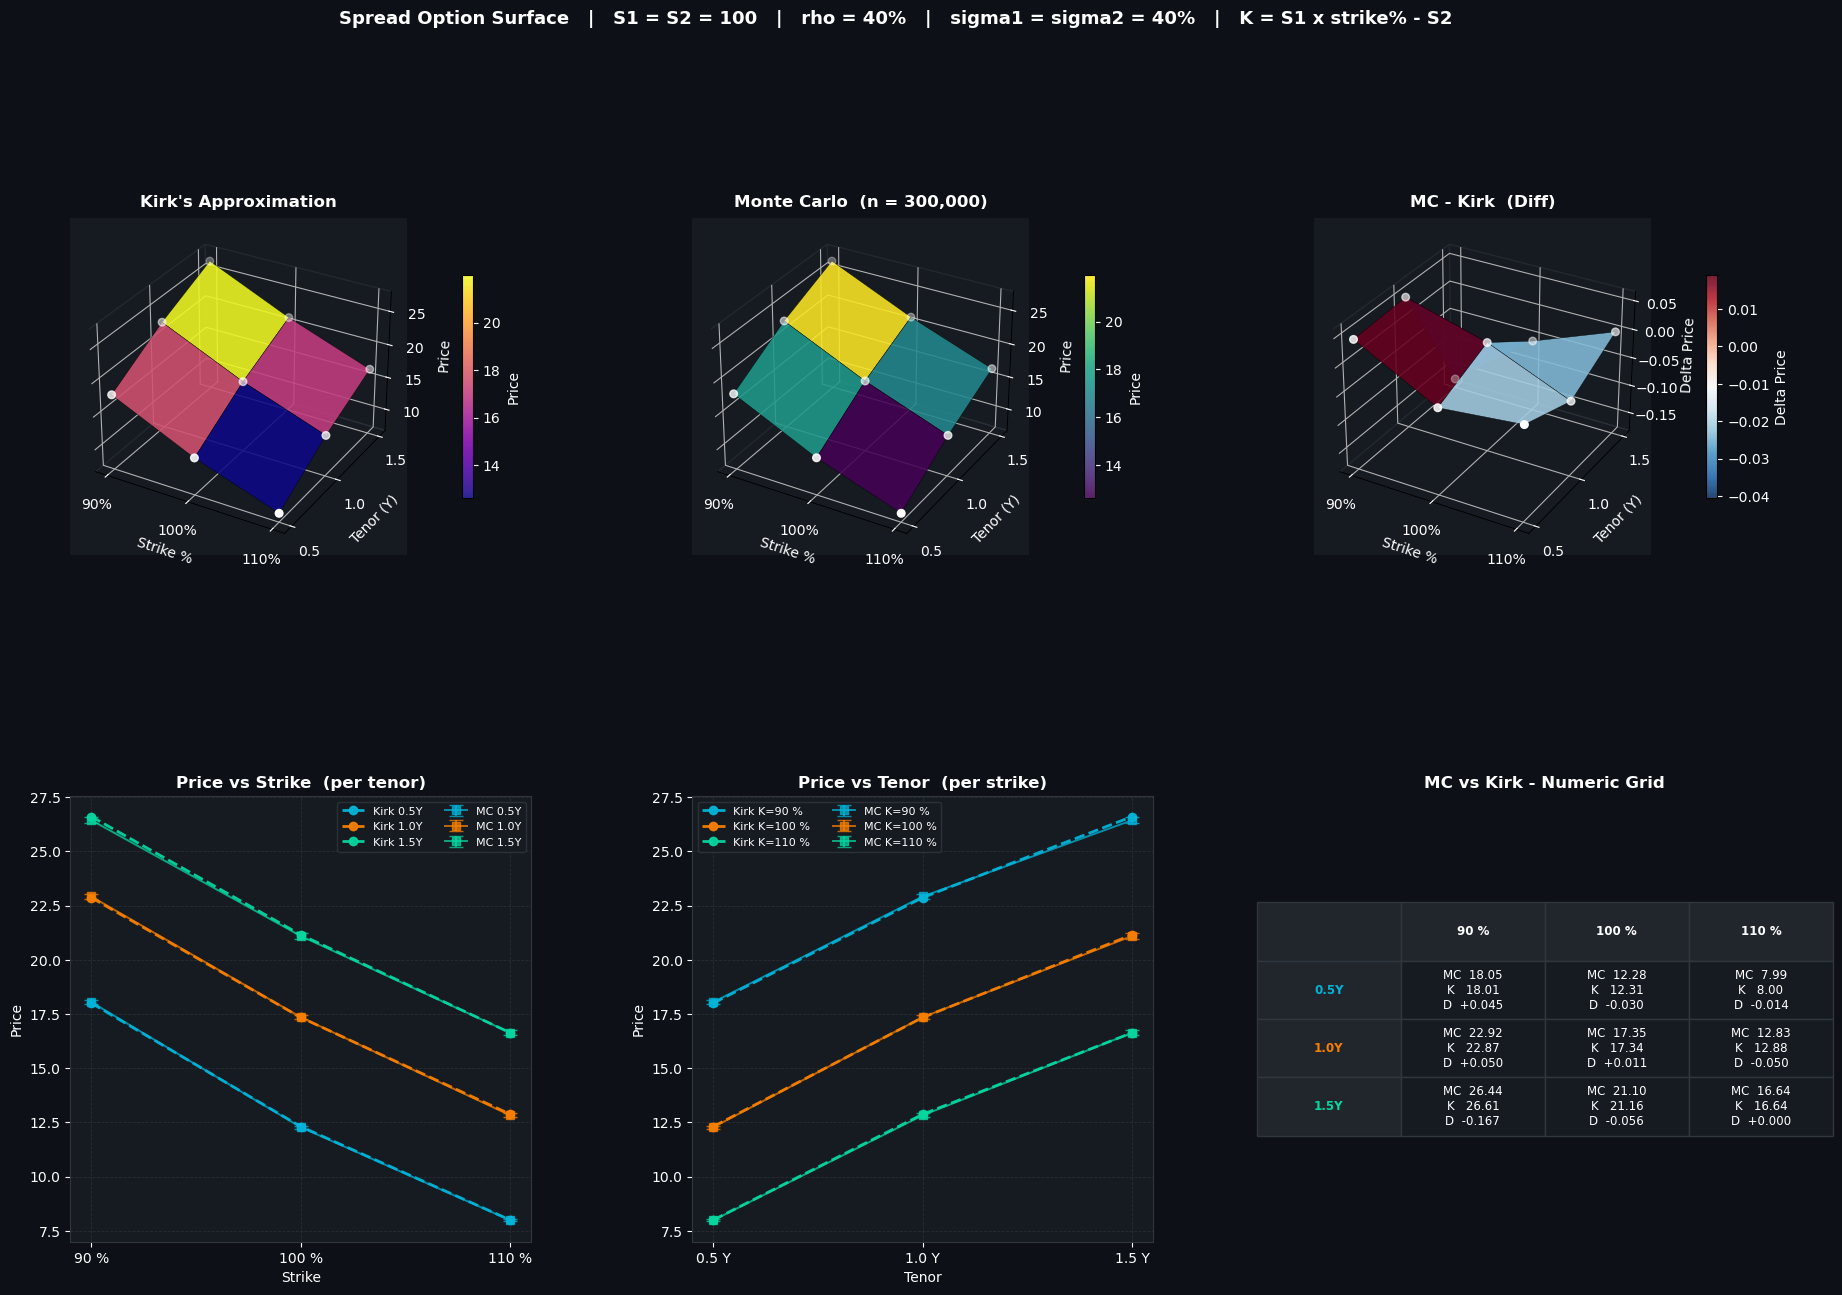

Saved: spread_option_surface.png


In [6]:
DARK_AX  = "#161b22"
GRID_COL = "#30363d"
COLORS   = ["#00b4d8", "#f77f00", "#06d6a0"]

Tm, Km = np.meshgrid(TENORS, STRIKE_PCTS, indexing="ij")   # (3, 3)

def style_3d(ax, title):
    ax.set_facecolor(DARK_AX)
    ax.xaxis.pane.fill = False; ax.yaxis.pane.fill = False; ax.zaxis.pane.fill = False
    ax.xaxis.pane.set_edgecolor(GRID_COL)
    ax.yaxis.pane.set_edgecolor(GRID_COL)
    ax.zaxis.pane.set_edgecolor(GRID_COL)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
    ax.zaxis.label.set_color("white")
    ax.set_title(title, color="white", fontweight="bold", pad=8)

def style_2d(ax, title):
    ax.set_facecolor(DARK_AX)
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white"); ax.yaxis.label.set_color("white")
    ax.set_title(title, color="white", fontweight="bold")
    ax.spines[["bottom","top","left","right"]].set_edgecolor(GRID_COL)
    ax.grid(True, color=GRID_COL, linewidth=0.6, linestyle="--", alpha=0.7)


fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor("#0d1117")
fig.suptitle(
    f"Spread Option Surface   |   S1 = S2 = {S1:.0f}   |   rho = {RHO:.0%}   |   "
    f"sigma1 = sigma2 = {SIGMA:.0%}   |   K = S1 x strike% - S2",
    color="white", fontsize=13, fontweight="bold", y=0.99
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)


# ── 1. Kirk 3-D surface ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0], projection="3d")
surf1 = ax1.plot_surface(Km, Tm, kirk_surf, cmap="plasma",
                         alpha=0.88, edgecolor="k", linewidth=0.3)
ax1.scatter(Km.ravel(), Tm.ravel(), kirk_surf.ravel(), color="white", s=30, zorder=5)
style_3d(ax1, "Kirk's Approximation")
ax1.set_xlabel("Strike %"); ax1.set_ylabel("Tenor (Y)"); ax1.set_zlabel("Price")
ax1.set_xticks(STRIKE_PCTS); ax1.set_xticklabels(["90%","100%","110%"])
ax1.set_yticks(TENORS)
cb1 = fig.colorbar(surf1, ax=ax1, shrink=0.5, pad=0.12)
cb1.set_label("Price", color="white")
cb1.ax.yaxis.set_tick_params(color="white", labelcolor="white")


# ── 2. MC 3-D surface ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1], projection="3d")
surf2 = ax2.plot_surface(Km, Tm, mc_surf, cmap="viridis",
                         alpha=0.88, edgecolor="k", linewidth=0.3)
ax2.scatter(Km.ravel(), Tm.ravel(), mc_surf.ravel(), color="white", s=30, zorder=5)
style_3d(ax2, f"Monte Carlo  (n = {N_SIMS:,})")
ax2.set_xlabel("Strike %"); ax2.set_ylabel("Tenor (Y)"); ax2.set_zlabel("Price")
ax2.set_xticks(STRIKE_PCTS); ax2.set_xticklabels(["90%","100%","110%"])
ax2.set_yticks(TENORS)
cb2 = fig.colorbar(surf2, ax=ax2, shrink=0.5, pad=0.12)
cb2.set_label("Price", color="white")
cb2.ax.yaxis.set_tick_params(color="white", labelcolor="white")


# ── 3. Difference MC - Kirk ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2], projection="3d")
surf3 = ax3.plot_surface(Km, Tm, diff_surf, cmap="RdBu_r",
                         alpha=0.88, edgecolor="k", linewidth=0.3)
ax3.scatter(Km.ravel(), Tm.ravel(), diff_surf.ravel(), color="white", s=30, zorder=5)
style_3d(ax3, "MC - Kirk  (Diff)")
ax3.set_xlabel("Strike %"); ax3.set_ylabel("Tenor (Y)"); ax3.set_zlabel("Delta Price")
ax3.set_xticks(STRIKE_PCTS); ax3.set_xticklabels(["90%","100%","110%"])
ax3.set_yticks(TENORS)
cb3 = fig.colorbar(surf3, ax=ax3, shrink=0.5, pad=0.12)
cb3.set_label("Delta Price", color="white")
cb3.ax.yaxis.set_tick_params(color="white", labelcolor="white")


# ── 4. Price vs Strike (one line per tenor) ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
style_2d(ax4, "Price vs Strike  (per tenor)")
for i, (T, c) in enumerate(zip(TENORS, COLORS)):
    ax4.plot(STRIKE_LABELS, kirk_surf[i], "o--", color=c, lw=2,
             label=f"Kirk {T}Y", alpha=0.95)
    ax4.errorbar(STRIKE_LABELS, mc_surf[i], yerr=2*mc_err[i], fmt="s-",
                 color=c, lw=1.4, capsize=5, label=f"MC {T}Y", alpha=0.75)
ax4.set_xlabel("Strike"); ax4.set_ylabel("Price")
ax4.legend(fontsize=8, ncol=2, facecolor=DARK_AX, edgecolor=GRID_COL,
           labelcolor="white")


# ── 5. Price vs Tenor (one line per strike) ──────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
style_2d(ax5, "Price vs Tenor  (per strike)")
for j, (lbl, c) in enumerate(zip(STRIKE_LABELS, COLORS)):
    ax5.plot(TENOR_LABELS, kirk_surf[:, j], "o--", color=c, lw=2,
             label=f"Kirk K={lbl}", alpha=0.95)
    ax5.errorbar(TENOR_LABELS, mc_surf[:, j], yerr=2*mc_err[:, j], fmt="s-",
                 color=c, lw=1.4, capsize=5, label=f"MC K={lbl}", alpha=0.75)
ax5.set_xlabel("Tenor"); ax5.set_ylabel("Price")
ax5.legend(fontsize=8, ncol=2, facecolor=DARK_AX, edgecolor=GRID_COL,
           labelcolor="white")


# ── 6. Numeric summary table ─────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(DARK_AX)
ax6.set_title("MC vs Kirk - Numeric Grid", color="white", fontweight="bold")
ax6.axis("off")

col_hdrs = [""] + STRIKE_LABELS
row_list = []
for i, T in enumerate(TENORS):
    r_ = [f"{T}Y"]
    for j in range(n_K):
        r_.append(
            f"MC  {mc_surf[i,j]:.2f}\n"
            f"K   {kirk_surf[i,j]:.2f}\n"
            f"D  {diff_surf[i,j]:+.3f}"
        )
    row_list.append(r_)

tbl = ax6.table(
    cellText=row_list, colLabels=col_hdrs,
    loc="center", cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.25, 3.5)

for (ri, ci), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID_COL)
    if ri == 0:
        cell.set_facecolor("#21262d")
        cell.get_text().set_color("white")
        cell.get_text().set_fontweight("bold")
    elif ci == 0:
        cell.set_facecolor("#21262d")
        cell.get_text().set_color(COLORS[ri - 1])
        cell.get_text().set_fontweight("bold")
    else:
        cell.set_facecolor(DARK_AX)
        cell.get_text().set_color("white")


plt.savefig("spread_option_surface.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved: spread_option_surface.png")

## 7 · Calibration — MC fit to Kirk Surface

Use the Kirk surface computed above as the **target**. Starting from user-supplied initial parameters, run a global optimisation (Differential Evolution) to recover **ρ, σ₁, σ₂** that minimise the sum-of-squared-errors between MC prices and the target.

**Key trick:** random numbers are drawn **once** and reused at every objective evaluation — this makes the loss function smooth and deterministic, so gradient-free methods converge reliably.

In [7]:
# ── User-editable initial parameters ─────────────────────────────────────────
INIT_RHO   = 0.50   # initial correlation
INIT_SIG1  = 0.30   # initial vol asset 1
INIT_SIG2  = 0.10   # initial vol asset 2

# Bounds for the optimiser
BOUNDS_RHO  = (-0.999,  0.999)
BOUNDS_SIG1 = ( 0.010,  1.000)
BOUNDS_SIG2 = ( 0.010,  1.000)

# MC paths used inside each objective evaluation
# More paths → lower noise → smoother loss → better convergence (but slower)
N_CALIB    = 500_000
CALIB_SEED = 999     # fixed seed → fully deterministic objective

print(f"Initial guess:  ρ = {INIT_RHO:.4f}   σ₁ = {INIT_SIG1:.4f}   σ₂ = {INIT_SIG2:.4f}")
print(f"True params:    ρ = {RHO:.4f}   σ₁ = {SIGMA:.4f}   σ₂ = {SIGMA:.4f}")
print(f"Target surface (Kirk):\n{np.round(kirk_surf, 4)}")

Initial guess:  ρ = 0.5000   σ₁ = 0.3000   σ₂ = 0.1000
True params:    ρ = 0.4000   σ₁ = 0.4000   σ₂ = 0.4000
Target surface (Kirk):
[[18.006  12.3115  8.0048]
 [22.8683 17.3419 12.8804]
 [26.606  21.1553 16.6377]]


In [8]:
from scipy.optimize import differential_evolution

# ── Pre-generate random draws once — reused at every objective call ───────────
_rng   = np.random.default_rng(CALIB_SEED)
_Z_raw = _rng.standard_normal((2, N_CALIB))   # shape (2, N_CALIB)

TARGET = kirk_surf.copy()   # 3×3 target surface

def mc_surface(sig1, sig2, rho):
    """Price the full 3×3 surface using the pre-generated normals."""
    Z1 = _Z_raw[0]
    Z2 = rho * _Z_raw[0] + np.sqrt(max(1.0 - rho**2, 0.0)) * _Z_raw[1]
    surf = np.zeros((len(TENORS), len(STRIKES)))
    for i, T in enumerate(TENORS):
        sqT  = np.sqrt(T)
        ST1  = S1 * np.exp((R - 0.5*sig1**2)*T + sig1*sqT*Z1)
        ST2  = S2 * np.exp((R - 0.5*sig2**2)*T + sig2*sqT*Z2)
        for j, K in enumerate(STRIKES):
            surf[i, j] = np.maximum(ST1 - ST2 - K, 0.0).mean()   # r = 0
    return surf

_n_calls = [0]

def objective(params):
    """SSE between MC surface and Kirk target. Params = [sig1, sig2, rho]."""
    sig1, sig2, rho = params
    _n_calls[0] += 1
    diff = mc_surface(sig1, sig2, rho) - TARGET
    return float(np.sum(diff**2))

# Sanity-check at initial guess
sse0 = objective([INIT_SIG1, INIT_SIG2, INIT_RHO])
print(f"SSE at initial guess:  {sse0:.6f}")
print(f"(MC surface at initial guess vs target)")
print(np.round(mc_surface(INIT_SIG1, INIT_SIG2, INIT_RHO) - TARGET, 4))

SSE at initial guess:  397.531910
(MC surface at initial guess vs target)
[[-4.8527 -4.839  -4.1284]
 [-7.122  -6.7891 -6.0314]
 [-8.7803 -8.2489 -7.4293]]


In [12]:
import time

# Bounds order matches objective params: [sig1, sig2, rho]
bounds = [BOUNDS_SIG1, BOUNDS_SIG2, BOUNDS_RHO]

_n_calls[0] = 0
print("Running Differential Evolution (global search)...")
print("(this may take ~1–3 min depending on hardware)\n")

t0 = time.time()
de_result = differential_evolution(
    objective, bounds,
    x0=[INIT_SIG1, INIT_SIG2, INIT_RHO],   # warm-start the initial individual
    seed=0,
    maxiter=30,
    tol=0.01,
    mutation=(0.5, 1.5),
    recombination=0.9,
    popsize=15,
    polish=True,     # L-BFGS-B local refinement after DE
    disp=True,
    workers=1,
)
t_elapsed = time.time() - t0

opt_sig1, opt_sig2, opt_rho = de_result.x

sep = "─" * 58
print(f"\n{sep}")
print(f"  DE finished in {t_elapsed:.1f}s  |  {_n_calls[0]} objective calls")
print(sep)
print(f"  {'Parameter':<12} {'Initial':>10} {'Recovered':>12} {'True':>10}")
print(sep)
print(f"  {'ρ':<12} {INIT_RHO:>10.4f} {opt_rho:>12.4f} {RHO:>10.4f}")
print(f"  {'σ₁':<12} {INIT_SIG1:>10.4f} {opt_sig1:>12.4f} {SIGMA:>10.4f}")
print(f"  {'σ₂':<12} {INIT_SIG2:>10.4f} {opt_sig2:>12.4f} {SIGMA:>10.4f}")
print(sep)
print(f"  Final SSE : {de_result.fun:.8f}")
print(f"  Converged : {de_result.success}  |  {de_result.message}")

Running Differential Evolution (global search)...
(this may take ~1–3 min depending on hardware)

differential_evolution step 1: f(x)= 0.35638660724912846
differential_evolution step 2: f(x)= 0.35638660724912846
differential_evolution step 3: f(x)= 0.35638660724912846
differential_evolution step 4: f(x)= 0.35638660724912846
differential_evolution step 5: f(x)= 0.35638660724912846
differential_evolution step 6: f(x)= 0.35638660724912846
differential_evolution step 7: f(x)= 0.35638660724912846
differential_evolution step 8: f(x)= 0.35638660724912846
differential_evolution step 9: f(x)= 0.35638660724912846
differential_evolution step 10: f(x)= 0.35638660724912846
differential_evolution step 11: f(x)= 0.35638660724912846
differential_evolution step 12: f(x)= 0.07974817673614422
differential_evolution step 13: f(x)= 0.07974817673614422
differential_evolution step 14: f(x)= 0.07411462434695519
differential_evolution step 15: f(x)= 0.07061527259796918
differential_evolution step 16: f(x)= 0.0

In [13]:
print(f"  {'Parameter':<12} {'Initial':>10} {'Recovered':>12} {'True':>10}")
print(sep)
print(f"  {'ρ':<12} {INIT_RHO:>10.4f} {opt_rho:>12.4f} {RHO:>10.4f}")
print(f"  {'σ₁':<12} {INIT_SIG1:>10.4f} {opt_sig1:>12.4f} {SIGMA:>10.4f}")
print(f"  {'σ₂':<12} {INIT_SIG2:>10.4f} {opt_sig2:>12.4f} {SIGMA:>10.4f}")

  Parameter       Initial    Recovered       True
──────────────────────────────────────────────────────────
  ρ                0.5000       0.4757     0.4000
  σ₁               0.3000       0.4284     0.4000
  σ₂               0.1000       0.4252     0.4000


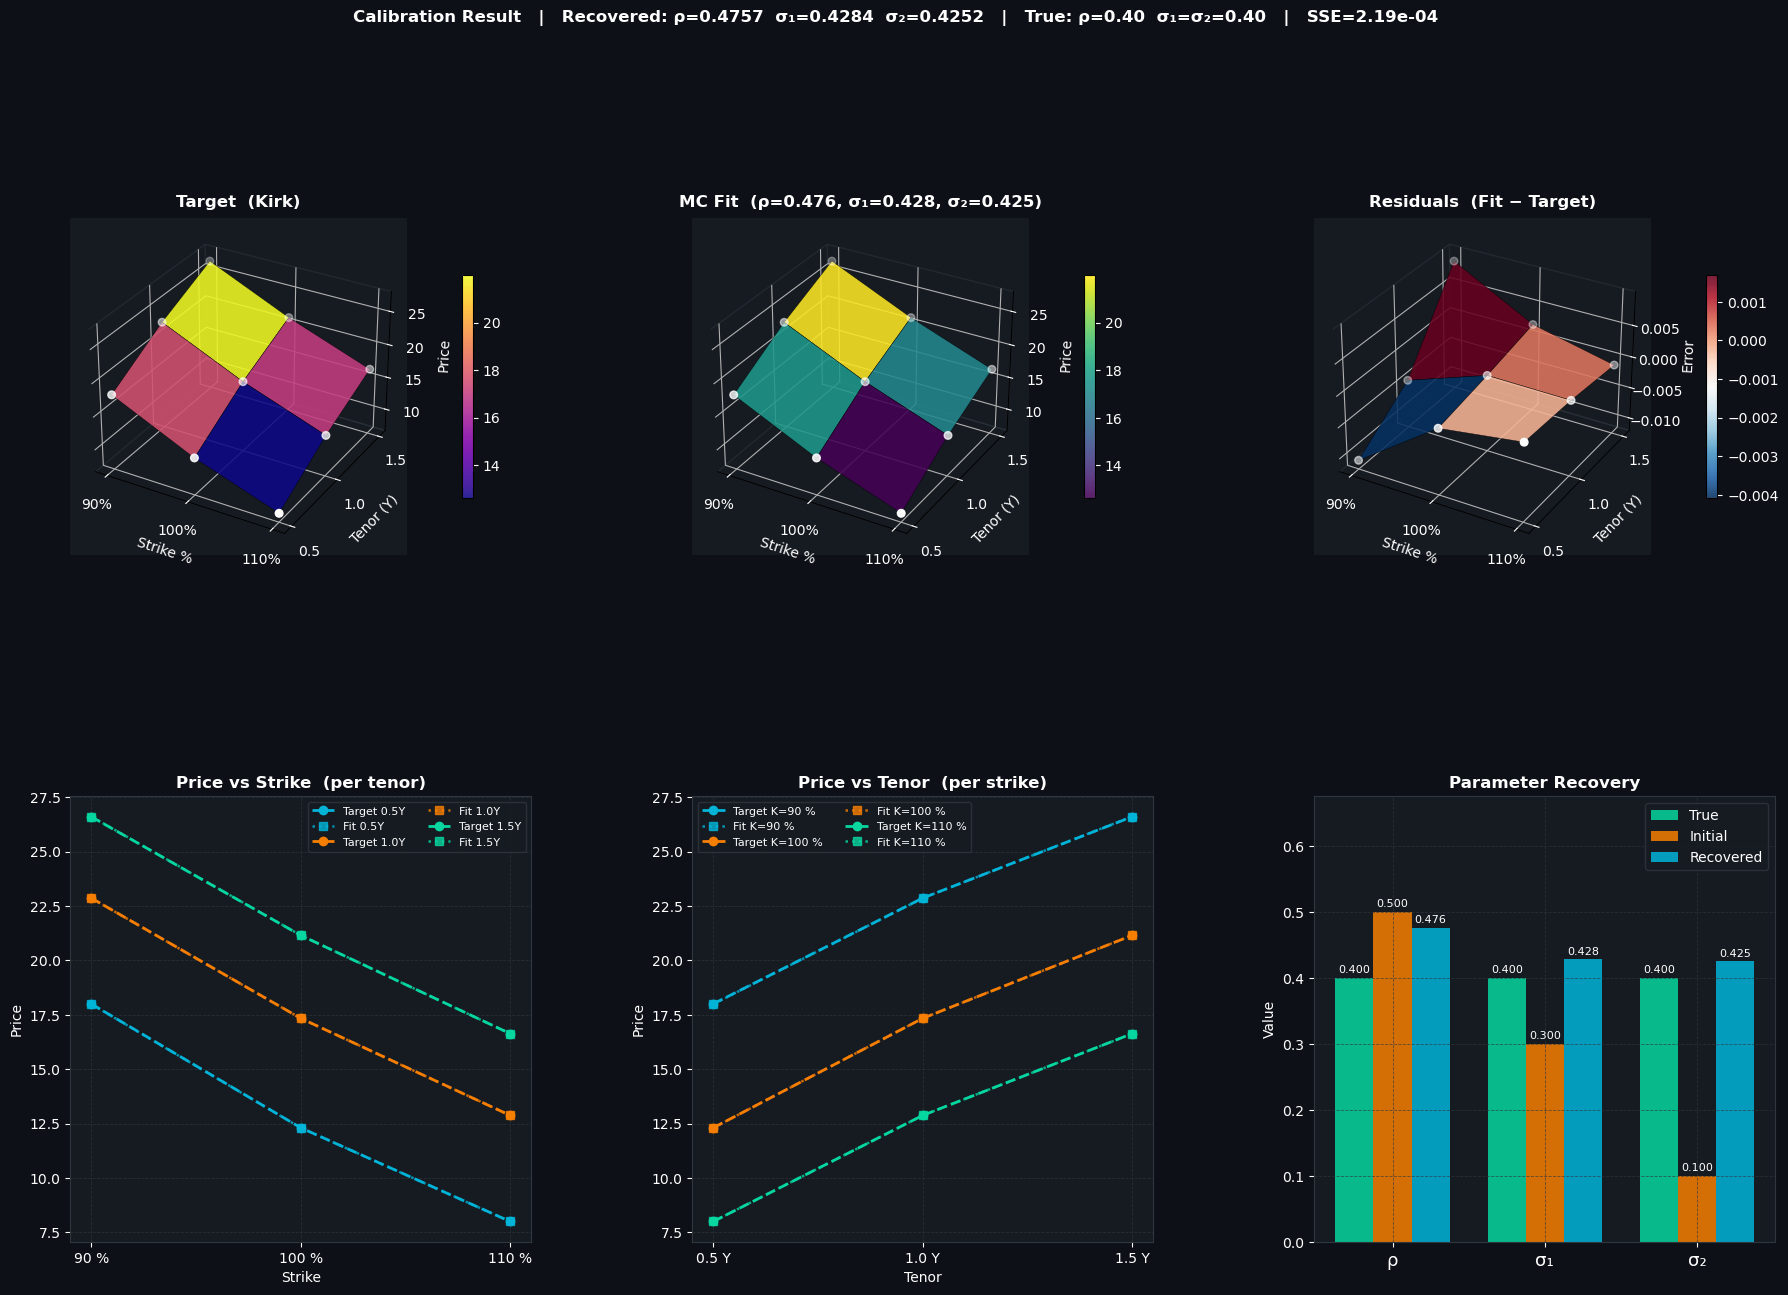

Saved: spread_option_calibration.png


In [11]:
# ── Calibration results plot ──────────────────────────────────────────────────
fit_surf = mc_surface(opt_sig1, opt_sig2, opt_rho)
resid    = fit_surf - TARGET

fig2 = plt.figure(figsize=(22, 14))
fig2.patch.set_facecolor("#0d1117")
fig2.suptitle(
    f"Calibration Result   |   "
    f"Recovered: ρ={opt_rho:.4f}  σ₁={opt_sig1:.4f}  σ₂={opt_sig2:.4f}   |   "
    f"True: ρ={RHO:.2f}  σ₁=σ₂={SIGMA:.2f}   |   SSE={de_result.fun:.2e}",
    color="white", fontsize=12, fontweight="bold", y=0.99,
)

gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.42, wspace=0.35)

# ── 3-D: Target ──────────────────────────────────────────────────────────────
ax_t = fig2.add_subplot(gs2[0, 0], projection="3d")
s_t  = ax_t.plot_surface(Km, Tm, TARGET, cmap="plasma",
                          alpha=0.88, edgecolor="k", linewidth=0.3)
ax_t.scatter(Km.ravel(), Tm.ravel(), TARGET.ravel(), color="white", s=30, zorder=5)
style_3d(ax_t, "Target  (Kirk)")
ax_t.set_xlabel("Strike %"); ax_t.set_ylabel("Tenor (Y)"); ax_t.set_zlabel("Price")
ax_t.set_xticks(STRIKE_PCTS); ax_t.set_xticklabels(["90%","100%","110%"])
ax_t.set_yticks(TENORS)
fig2.colorbar(s_t, ax=ax_t, shrink=0.5, pad=0.12).ax.yaxis.set_tick_params(
    color="white", labelcolor="white")

# ── 3-D: Fitted ──────────────────────────────────────────────────────────────
ax_f = fig2.add_subplot(gs2[0, 1], projection="3d")
s_f  = ax_f.plot_surface(Km, Tm, fit_surf, cmap="viridis",
                          alpha=0.88, edgecolor="k", linewidth=0.3)
ax_f.scatter(Km.ravel(), Tm.ravel(), fit_surf.ravel(), color="white", s=30, zorder=5)
style_3d(ax_f, f"MC Fit  (ρ={opt_rho:.3f}, σ₁={opt_sig1:.3f}, σ₂={opt_sig2:.3f})")
ax_f.set_xlabel("Strike %"); ax_f.set_ylabel("Tenor (Y)"); ax_f.set_zlabel("Price")
ax_f.set_xticks(STRIKE_PCTS); ax_f.set_xticklabels(["90%","100%","110%"])
ax_f.set_yticks(TENORS)
fig2.colorbar(s_f, ax=ax_f, shrink=0.5, pad=0.12).ax.yaxis.set_tick_params(
    color="white", labelcolor="white")

# ── 3-D: Residuals ────────────────────────────────────────────────────────────
ax_r = fig2.add_subplot(gs2[0, 2], projection="3d")
s_r  = ax_r.plot_surface(Km, Tm, resid, cmap="RdBu_r",
                          alpha=0.88, edgecolor="k", linewidth=0.3)
ax_r.scatter(Km.ravel(), Tm.ravel(), resid.ravel(), color="white", s=30, zorder=5)
style_3d(ax_r, "Residuals  (Fit − Target)")
ax_r.set_xlabel("Strike %"); ax_r.set_ylabel("Tenor (Y)"); ax_r.set_zlabel("Error")
ax_r.set_xticks(STRIKE_PCTS); ax_r.set_xticklabels(["90%","100%","110%"])
ax_r.set_yticks(TENORS)
fig2.colorbar(s_r, ax=ax_r, shrink=0.5, pad=0.12).ax.yaxis.set_tick_params(
    color="white", labelcolor="white")

# ── 2-D: Price vs Strike per tenor ───────────────────────────────────────────
ax4b = fig2.add_subplot(gs2[1, 0])
style_2d(ax4b, "Price vs Strike  (per tenor)")
for i, (T, c) in enumerate(zip(TENORS, COLORS)):
    ax4b.plot(STRIKE_LABELS, TARGET[i],   "o--", color=c, lw=2,   label=f"Target {T}Y")
    ax4b.plot(STRIKE_LABELS, fit_surf[i], "s:",  color=c, lw=1.8, label=f"Fit {T}Y", alpha=0.8)
ax4b.set_xlabel("Strike"); ax4b.set_ylabel("Price")
ax4b.legend(fontsize=8, ncol=2, facecolor=DARK_AX, edgecolor=GRID_COL, labelcolor="white")

# ── 2-D: Price vs Tenor per strike ───────────────────────────────────────────
ax5b = fig2.add_subplot(gs2[1, 1])
style_2d(ax5b, "Price vs Tenor  (per strike)")
for j, (lbl, c) in enumerate(zip(STRIKE_LABELS, COLORS)):
    ax5b.plot(TENOR_LABELS, TARGET[:, j],   "o--", color=c, lw=2,   label=f"Target K={lbl}")
    ax5b.plot(TENOR_LABELS, fit_surf[:, j], "s:",  color=c, lw=1.8, label=f"Fit K={lbl}", alpha=0.8)
ax5b.set_xlabel("Tenor"); ax5b.set_ylabel("Price")
ax5b.legend(fontsize=8, ncol=2, facecolor=DARK_AX, edgecolor=GRID_COL, labelcolor="white")

# ── Parameter recovery bar chart ─────────────────────────────────────────────
ax6b = fig2.add_subplot(gs2[1, 2])
style_2d(ax6b, "Parameter Recovery")
param_names = ["ρ", "σ₁", "σ₂"]
true_vals   = [RHO,   SIGMA,    SIGMA   ]
init_vals   = [INIT_RHO, INIT_SIG1, INIT_SIG2]
opt_vals    = [opt_rho,  opt_sig1,  opt_sig2 ]
x = np.arange(len(param_names))
w = 0.25
ax6b.bar(x - w, true_vals, w, label="True",      color="#06d6a0", alpha=0.85)
ax6b.bar(x,     init_vals, w, label="Initial",   color="#f77f00", alpha=0.85)
ax6b.bar(x + w, opt_vals,  w, label="Recovered", color="#00b4d8", alpha=0.85)
ax6b.set_xticks(x)
ax6b.set_xticklabels(param_names, color="white", fontsize=13)
ax6b.set_ylabel("Value")
top = max(max(true_vals), max(init_vals), max(opt_vals)) * 1.35
ax6b.set_ylim(0, top)
for bars, vals in zip(
    [ax6b.containers[0], ax6b.containers[1], ax6b.containers[2]],
    [true_vals, init_vals, opt_vals]
):
    ax6b.bar_label(bars, labels=[f"{v:.3f}" for v in vals],
                   color="white", fontsize=8, padding=2)
ax6b.legend(facecolor=DARK_AX, edgecolor=GRID_COL, labelcolor="white")

plt.savefig("spread_option_calibration.png", dpi=150, bbox_inches="tight",
            facecolor=fig2.get_facecolor())
plt.show()
print("Saved: spread_option_calibration.png")